# 05 — Customer Segmentation
**Determine the clustering configuration and segment customers using Spark ML K-Means.**


## Objective
- Define the purpose of this stage.
- Record key decisions and assumptions.
- Keep outputs reproducible and easy to trace to the previous stage.


## Planned workflow
1. Load standardized customer features
2. Evaluate candidate K values with WCSS/Elbow
3. Evaluate candidate K values with Silhouette
4. Select K based on observed dataset results
5. Train final K-Means model
6. Profile cluster sizes and feature characteristics
7. Save customer-cluster assignments


In [ ]:
# Load standardized customer features from Parquet.
# K selection and final clustering will be performed here.


## Important
Do not hard-code a K value from a research paper. Select K using the metrics obtained from this dataset.


In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("ECommerceCustomerBehaviorAnalytics-05-Segmentation")
    .config("spark.sql.shuffle.partitions", "64")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 4.2.0


In [3]:
CLUSTERED_CUSTOMERS_PATH = "../data/clustered_customers_oct.parquet"

clustered_customers = spark.read.parquet(CLUSTERED_CUSTOMERS_PATH)

print("Rows:", clustered_customers.count())
print("Columns:", len(clustered_customers.columns))

clustered_customers.printSchema()

Rows: 347118
Columns: 9
root
 |-- user_id: integer (nullable = true)
 |-- cluster: integer (nullable = true)
 |-- recency_days: integer (nullable = true)
 |-- frequency: long (nullable = true)
 |-- monetary: double (nullable = true)
 |-- average_transaction_value: double (nullable = true)
 |-- avg_purchase_events_per_session: double (nullable = true)
 |-- amount_slope: double (nullable = true)
 |-- frequency_slope: double (nullable = true)



In [4]:
from pyspark.sql.functions import col

print("Distinct clusters:", clustered_customers.select("cluster").distinct().count())

print("\nCluster IDs:")
(
    clustered_customers
    .select("cluster")
    .distinct()
    .orderBy("cluster")
    .show()
)

print("Null cluster assignments:")
print(
    clustered_customers
    .filter(col("cluster").isNull())
    .count()
)

Distinct clusters: 6

Cluster IDs:
+-------+
|cluster|
+-------+
|      0|
|      1|
|      2|
|      3|
|      4|
|      5|
+-------+

Null cluster assignments:
0


In [5]:
from pyspark.sql.functions import avg, count, round, col

total_customers = clustered_customers.count()

cluster_profile = (
    clustered_customers
    .groupBy("cluster")
    .agg(
        count("*").alias("customers"),
        round(avg("recency_days"), 2).alias("avg_recency_days"),
        round(avg("frequency"), 2).alias("avg_frequency"),
        round(avg("monetary"), 2).alias("avg_monetary"),
        round(avg("average_transaction_value"), 2).alias("avg_transaction_value"),
        round(avg("avg_purchase_events_per_session"), 2).alias("avg_events_per_session"),
        round(avg("amount_slope"), 2).alias("avg_amount_slope"),
        round(avg("frequency_slope"), 2).alias("avg_frequency_slope")
    )
    .withColumn(
        "percentage",
        round(col("customers") / total_customers * 100, 2)
    )
    .orderBy("cluster")
)

cluster_profile.show(truncate=False)

+-------+---------+----------------+-------------+------------+---------------------+----------------------+----------------+-------------------+----------+
|cluster|customers|avg_recency_days|avg_frequency|avg_monetary|avg_transaction_value|avg_events_per_session|avg_amount_slope|avg_frequency_slope|percentage|
+-------+---------+----------------+-------------+------------+---------------------+----------------------+----------------+-------------------+----------+
|0      |99824    |17.31           |1.2          |70.83       |61.94                |1.01                  |22.98           |0.0                |28.76     |
|1      |15363    |15.72           |2.86         |1018.87     |340.98               |1.87                  |-59741.8        |0.0                |4.43      |
|2      |123777   |18.59           |1.32         |546.1       |423.91               |1.0                   |279.5           |0.0                |35.66     |
|3      |59926    |3.86            |1.62         |422.33  

/Users/vaishnavipoojary/Desktop/ecommerce-customer-behavior-analytics/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


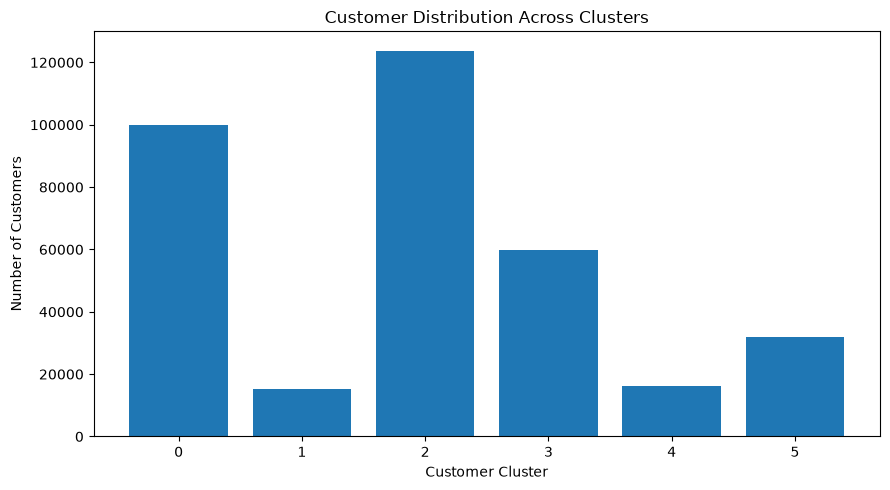

In [6]:
import matplotlib.pyplot as plt

cluster_size_pd = (
    cluster_profile
    .select("cluster", "customers", "percentage")
    .orderBy("cluster")
    .toPandas()
)

plt.figure(figsize=(9, 5))

plt.bar(
    cluster_size_pd["cluster"].astype(str),
    cluster_size_pd["customers"]
)

plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution Across Clusters")

plt.tight_layout()
plt.show()

/Users/vaishnavipoojary/Desktop/ecommerce-customer-behavior-analytics/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


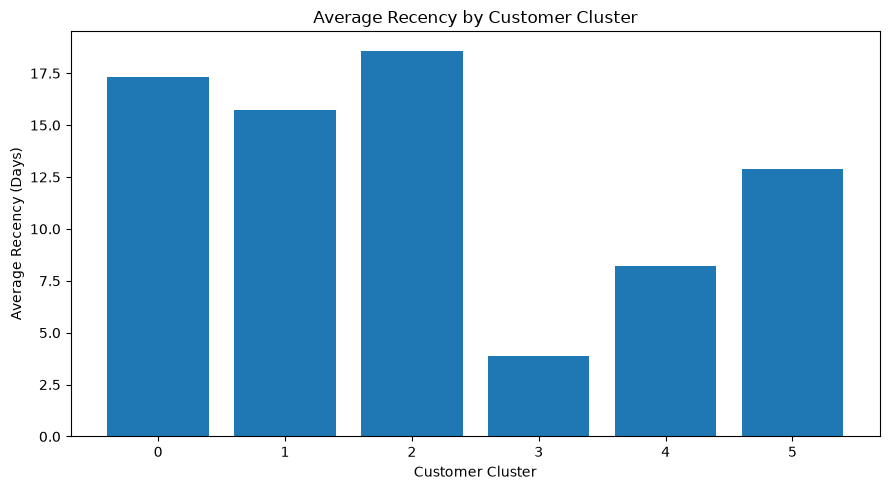

In [7]:
plt.figure(figsize=(9, 5))

plt.bar(
    cluster_size_pd["cluster"].astype(str),
    cluster_profile
        .orderBy("cluster")
        .select("avg_recency_days")
        .toPandas()["avg_recency_days"]
)

plt.xlabel("Customer Cluster")
plt.ylabel("Average Recency (Days)")
plt.title("Average Recency by Customer Cluster")

plt.tight_layout()
plt.show()

/Users/vaishnavipoojary/Desktop/ecommerce-customer-behavior-analytics/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


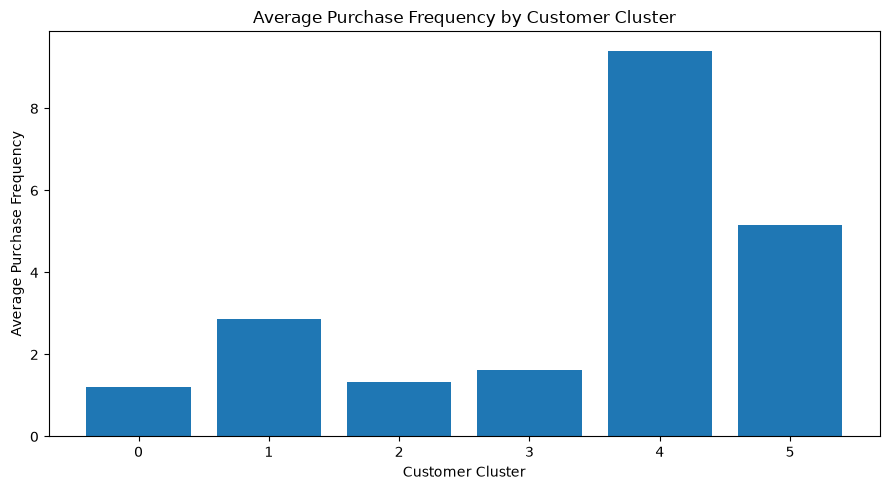

In [8]:
frequency_pd = (
    cluster_profile
    .orderBy("cluster")
    .select("cluster", "avg_frequency")
    .toPandas()
)

plt.figure(figsize=(9, 5))

plt.bar(
    frequency_pd["cluster"].astype(str),
    frequency_pd["avg_frequency"]
)

plt.xlabel("Customer Cluster")
plt.ylabel("Average Purchase Frequency")
plt.title("Average Purchase Frequency by Customer Cluster")

plt.tight_layout()
plt.show()

/Users/vaishnavipoojary/Desktop/ecommerce-customer-behavior-analytics/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


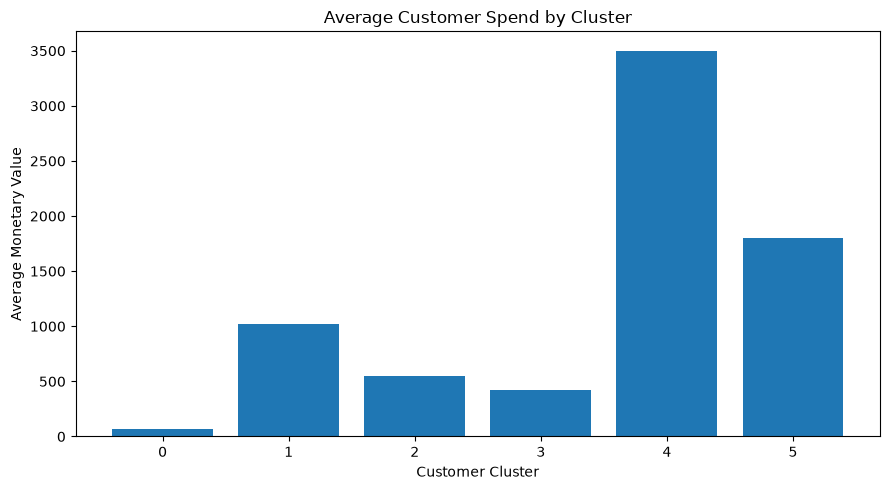

In [9]:
monetary_pd = (
    cluster_profile
    .orderBy("cluster")
    .select("cluster", "avg_monetary")
    .toPandas()
)

plt.figure(figsize=(9, 5))

plt.bar(
    monetary_pd["cluster"].astype(str),
    monetary_pd["avg_monetary"]
)

plt.xlabel("Customer Cluster")
plt.ylabel("Average Monetary Value")
plt.title("Average Customer Spend by Cluster")

plt.tight_layout()
plt.show()

/Users/vaishnavipoojary/Desktop/ecommerce-customer-behavior-analytics/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


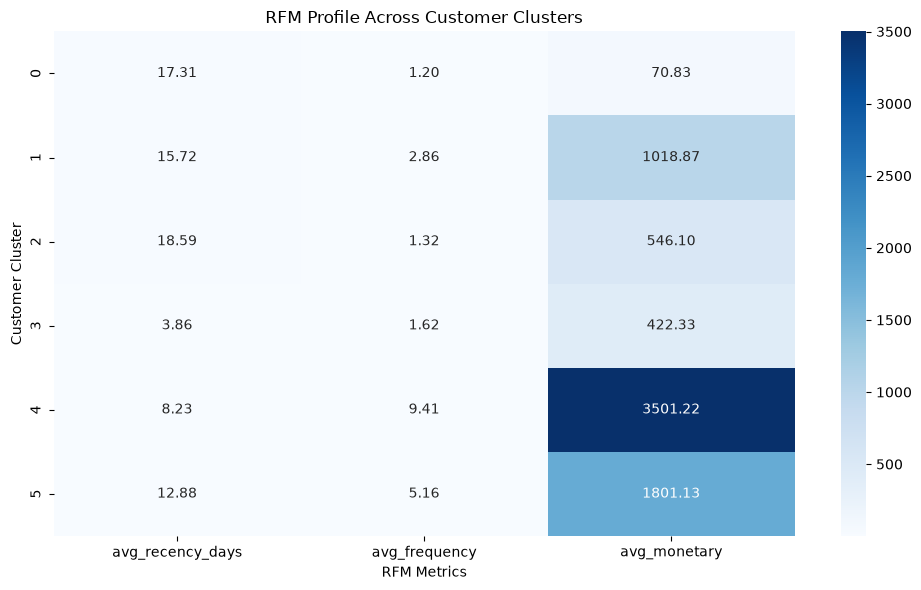

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

rfm_profile_pd = (
    cluster_profile
    .select(
        "cluster",
        "avg_recency_days",
        "avg_frequency",
        "avg_monetary"
    )
    .orderBy("cluster")
    .toPandas()
)

rfm_heatmap = rfm_profile_pd.set_index("cluster")

plt.figure(figsize=(10, 6))

sns.heatmap(
    rfm_heatmap,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("RFM Profile Across Customer Clusters")
plt.xlabel("RFM Metrics")
plt.ylabel("Customer Cluster")

plt.tight_layout()
plt.show()

/Users/vaishnavipoojary/Desktop/ecommerce-customer-behavior-analytics/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


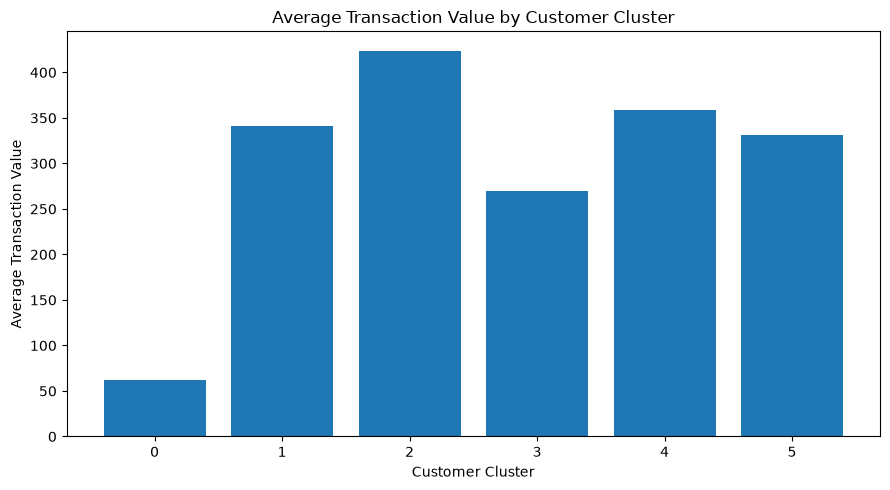

In [11]:
atv_pd = (
    cluster_profile
    .orderBy("cluster")
    .select("cluster", "avg_transaction_value")
    .toPandas()
)

plt.figure(figsize=(9, 5))

plt.bar(
    atv_pd["cluster"].astype(str),
    atv_pd["avg_transaction_value"]
)

plt.xlabel("Customer Cluster")
plt.ylabel("Average Transaction Value")
plt.title("Average Transaction Value by Customer Cluster")

plt.tight_layout()
plt.show()

/Users/vaishnavipoojary/Desktop/ecommerce-customer-behavior-analytics/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


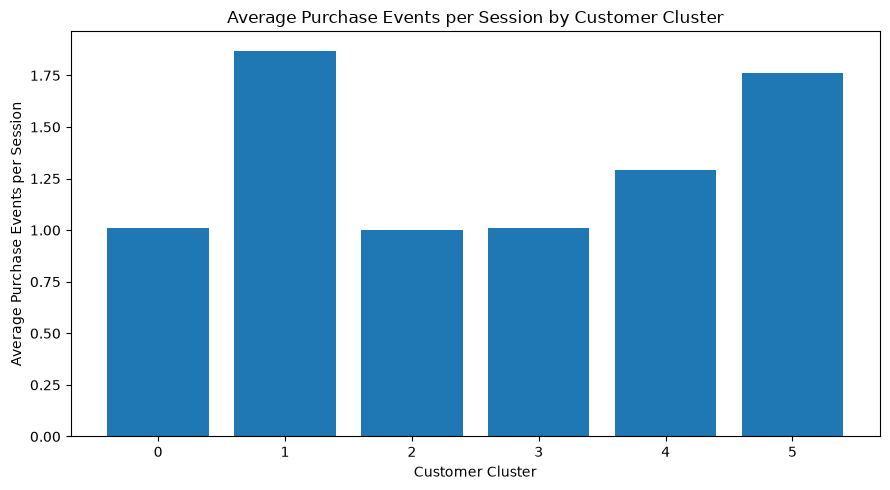

In [12]:
session_pd = (
    cluster_profile
    .orderBy("cluster")
    .select("cluster", "avg_events_per_session")
    .toPandas()
)

plt.figure(figsize=(9, 5))

plt.bar(
    session_pd["cluster"].astype(str),
    session_pd["avg_events_per_session"]
)

plt.xlabel("Customer Cluster")
plt.ylabel("Average Purchase Events per Session")
plt.title("Average Purchase Events per Session by Customer Cluster")

plt.tight_layout()
plt.show()

In [13]:
from pyspark.sql.functions import expr

In [14]:
slope_profile = (
    clustered_customers
    .groupBy("cluster")
    .agg(
        expr("percentile_approx(amount_slope, 0.5)").alias("median_amount_slope"),
        expr("percentile_approx(frequency_slope, 0.5)").alias("median_frequency_slope")
    )
    .orderBy("cluster")
)

slope_profile.show()

+-------+-------------------+----------------------+
|cluster|median_amount_slope|median_frequency_slope|
+-------+-------------------+----------------------+
|      0|                0.0|                   0.0|
|      1| -11117.22985074627|                   0.0|
|      2|                0.0|                   0.0|
|      3|                0.0|                   0.0|
|      4|-0.4498879513316326|                  -1.5|
|      5|                0.0|                   0.0|
+-------+-------------------+----------------------+



In [15]:
final_cluster_profile = (
    clustered_customers
    .groupBy("cluster")
    .agg(
        count("*").alias("customers"),
        round(avg("recency_days"), 2).alias("avg_recency"),
        round(avg("frequency"), 2).alias("avg_frequency"),
        round(avg("monetary"), 2).alias("avg_monetary"),
        round(avg("average_transaction_value"), 2).alias("avg_atv"),
        round(avg("avg_purchase_events_per_session"), 2).alias("avg_events_per_session")
    )
    .withColumn(
        "customer_percentage",
        round(col("customers") / total_customers * 100, 2)
    )
    .orderBy("cluster")
)

final_cluster_profile.show(truncate=False)

+-------+---------+-----------+-------------+------------+-------+----------------------+-------------------+
|cluster|customers|avg_recency|avg_frequency|avg_monetary|avg_atv|avg_events_per_session|customer_percentage|
+-------+---------+-----------+-------------+------------+-------+----------------------+-------------------+
|0      |99824    |17.31      |1.2          |70.83       |61.94  |1.01                  |28.76              |
|1      |15363    |15.72      |2.86         |1018.87     |340.98 |1.87                  |4.43               |
|2      |123777   |18.59      |1.32         |546.1       |423.91 |1.0                   |35.66              |
|3      |59926    |3.86       |1.62         |422.33      |270.17 |1.01                  |17.26              |
|4      |16156    |8.23       |9.41         |3501.22     |358.4  |1.29                  |4.65               |
|5      |32072    |12.88      |5.16         |1801.13     |331.63 |1.76                  |9.24               |
+-------+-

In [19]:
from pyspark.sql.functions import col, log1p, sign, abs as spark_abs
from pyspark.ml.feature import VectorAssembler, StandardScaler

# Recreate the seven Enhanced-RFM features
rfm_features = (
    clustered_customers
    .withColumn("recency_log", log1p(col("recency_days")))
    .withColumn("frequency_log", log1p(col("frequency")))
    .withColumn("monetary_log", log1p(col("monetary")))
    .withColumn("atv_log", log1p(col("average_transaction_value")))
    .withColumn(
        "events_session_log",
        log1p(col("avg_purchase_events_per_session"))
    )
    .withColumn(
        "amount_slope_transformed",
        sign(col("amount_slope")) * log1p(spark_abs(col("amount_slope")))
    )
    .withColumn(
        "frequency_slope_transformed",
        sign(col("frequency_slope")) * log1p(spark_abs(col("frequency_slope")))
    )
)

feature_columns = [
    "recency_log",
    "frequency_log",
    "monetary_log",
    "atv_log",
    "events_session_log",
    "amount_slope_transformed",
    "frequency_slope_transformed"
]

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

rfm_vector = assembler.transform(rfm_features)

scaler = StandardScaler(
    inputCol="features",
    outputCol="features_scaled",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(rfm_vector)

rfm_scaled = scaler_model.transform(rfm_vector)

print("Scaled feature matrix created successfully.")
print("Rows:", rfm_scaled.count())

[Stage 84:>                                                       (0 + 10) / 10]

Scaled feature matrix created successfully.
Rows: 347118


In [20]:
from pyspark.ml.feature import PCA

pca = PCA(
    k=2,
    inputCol="features_scaled",
    outputCol="pca_features"
)

pca_model = pca.fit(rfm_scaled)

pca_result = (
    pca_model
    .transform(rfm_scaled)
    .select("user_id", "pca_features")
)

pca_result = (
    pca_result
    .join(
        clustered_customers.select("user_id", "cluster"),
        on="user_id",
        how="inner"
    )
)

print("PCA dataset created successfully.")
print("Rows:", pca_result.count())

pca_result.show(5, truncate=False)

PCA dataset created successfully.
Rows: 347118
+---------+------------------------------------------+-------+
|user_id  |pca_features                              |cluster|
+---------+------------------------------------------+-------+
|303160429|[-0.12934668111489414,-1.0539518180164982]|2      |
|371877401|[-2.244127864181119,0.8111266461460702]   |0      |
|401021311|[-0.3292082862207581,-0.613005106315919]  |2      |
|403013066|[1.3394582024968285,-0.5531132148527412]  |5      |
|415873351|[1.3297452458446695,1.7815095874845157]   |5      |
+---------+------------------------------------------+-------+
only showing top 5 rows


In [22]:
from pyspark.ml.functions import vector_to_array

pca_plot_pd = (
    pca_result
    .withColumn("pca_array", vector_to_array("pca_features"))
    .select(
        "cluster",
        col("pca_array")[0].alias("PC1"),
        col("pca_array")[1].alias("PC2")
    )
    .sample(False, 0.10, seed=42)
    .toPandas()
)

print("PCA plotting data:", len(pca_plot_pd), "points")

/Users/vaishnavipoojary/Desktop/ecommerce-customer-behavior-analytics/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


PCA plotting data: 34572 points


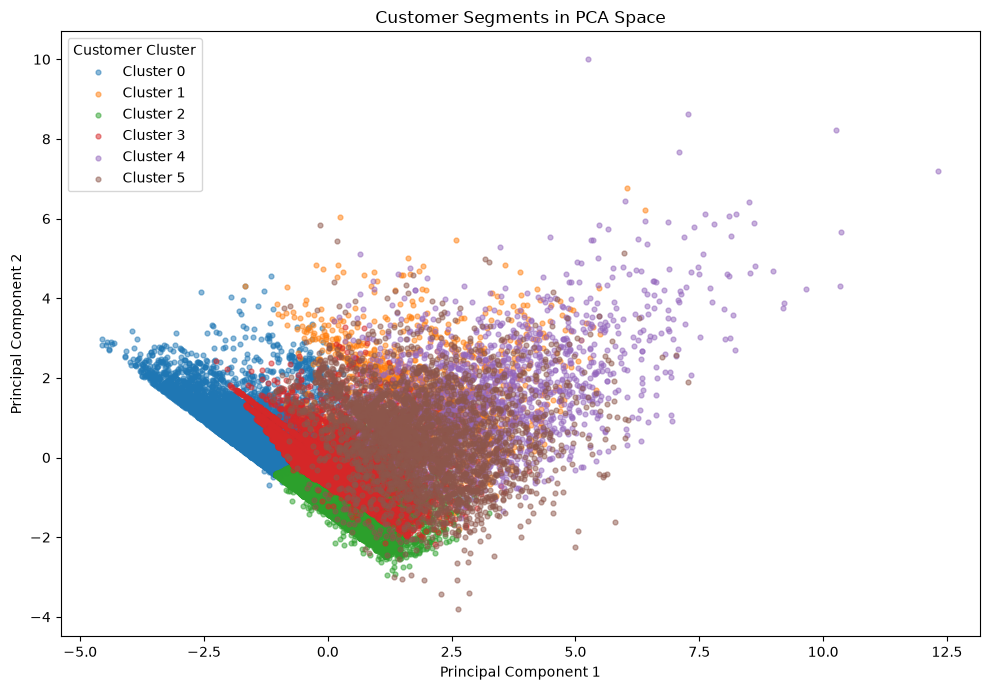

In [23]:
plt.figure(figsize=(10, 7))

for cluster_id in sorted(pca_plot_pd["cluster"].unique()):
    cluster_data = pca_plot_pd[
        pca_plot_pd["cluster"] == cluster_id
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster_id}",
        alpha=0.5,
        s=12
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments in PCA Space")
plt.legend(title="Customer Cluster")

plt.tight_layout()
plt.show()

In [24]:
final_cluster_profile_pd = final_cluster_profile.toPandas()

final_cluster_profile_pd.to_csv(
    "../outputs/tables/customer_cluster_profile.csv",
    index=False
)

print("Cluster profile saved successfully.")

/Users/vaishnavipoojary/Desktop/ecommerce-customer-behavior-analytics/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Cluster profile saved successfully.


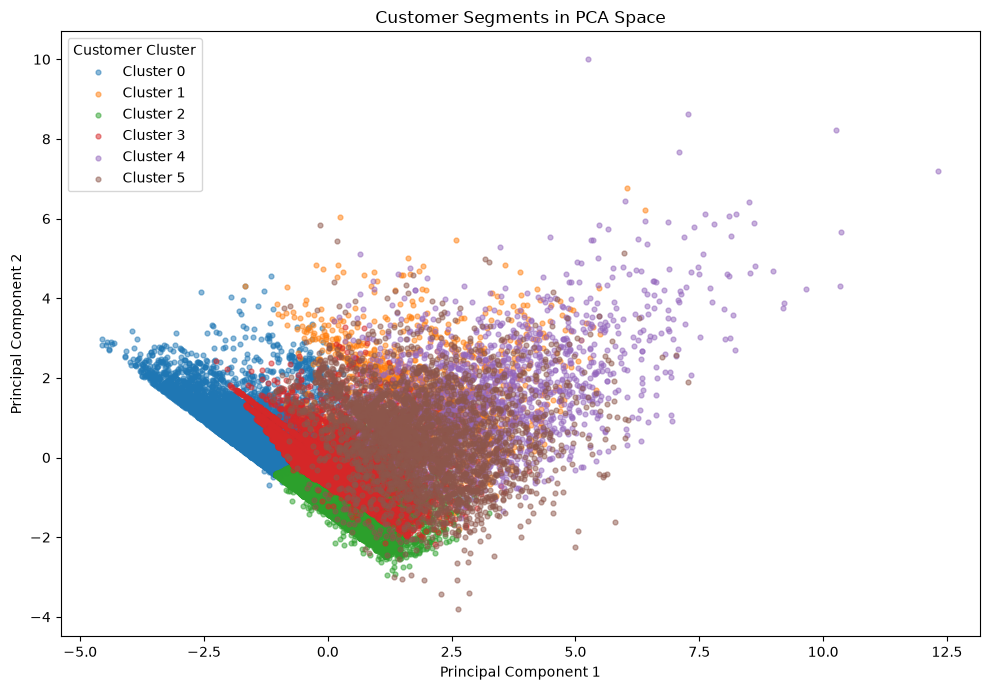

PCA visualization saved successfully.


In [25]:
plt.figure(figsize=(10, 7))

for cluster_id in sorted(pca_plot_pd["cluster"].unique()):
    cluster_data = pca_plot_pd[
        pca_plot_pd["cluster"] == cluster_id
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster_id}",
        alpha=0.5,
        s=12
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments in PCA Space")
plt.legend(title="Customer Cluster")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/customer_segments_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("PCA visualization saved successfully.")

## Final Customer Segmentation Summary

K-Means clustering was applied to 347,118 purchasing customers using seven standardized Enhanced-RFM features:

1. Recency
2. Frequency
3. Monetary
4. Average Transaction Value (ATV)
5. Average Purchase Events per Session
6. Amount Slope
7. Frequency Slope

The number of clusters was selected as **K = 6** using the Elbow method and Silhouette analysis performed in the Enhanced-RFM notebook. The final model was then applied to all 347,118 purchasing customers.

### Cluster Profiles

| Cluster | Customer Share | Avg Recency | Avg Frequency | Avg Monetary | Avg ATV | Avg Events/Session | Descriptive Profile |
|---|---:|---:|---:|---:|---:|---:|---|
| 0 | 28.76% | 17.31 | 1.20 | ₹70.83 | ₹61.94 | 1.01 | Low-Activity, Low-Spend Customers |
| 1 | 4.43% | 15.72 | 2.86 | ₹1,018.87 | ₹340.98 | 1.87 | Moderate-Frequency, High-Value Customers |
| 2 | 35.66% | 18.59 | 1.32 | ₹546.10 | ₹423.91 | 1.00 | Infrequent, High-ATV Customers |
| 3 | 17.26% | 3.86 | 1.62 | ₹422.33 | ₹270.17 | 1.01 | Recently Active, Low-Frequency Customers |
| 4 | 4.65% | 8.23 | 9.41 | ₹3,501.22 | ₹358.40 | 1.29 | High-Frequency, High-Value Customers |
| 5 | 9.24% | 12.88 | 5.16 | ₹1,801.13 | ₹331.63 | 1.76 | Frequent, High-Spend Customers |

### Key Observations

- Cluster 2 represents the largest customer group at 35.66% and combines low purchase frequency with a relatively high average transaction value.
- Cluster 0 contains 28.76% of customers and has the lowest average monetary value and ATV.
- Cluster 3 has the lowest average recency at 3.86 days, indicating the most recent purchasing activity among the clusters.
- Cluster 4 has the highest average purchase frequency (9.41) and monetary value (₹3,501.22).
- Cluster 5 also shows relatively high purchase frequency (5.16) and monetary value (₹1,801.13).
- Cluster 1 has moderate purchase frequency but relatively high monetary value and the highest average purchase events per session.
- The PCA visualization provides a two-dimensional view of the seven-dimensional feature space. Some overlap between clusters is expected because PCA compresses the original feature space into two dimensions.

### Dataset and Methodological Limitations

- The analysis uses the October 2019 event dataset only.
- The source data is event-level and does not contain an explicit order/transaction ID or quantity field.
- `user_session` is therefore used only as a session-level proxy and is not treated as a formal order identifier.
- Average Purchase Events per Session is a proxy for the paper's ABS feature rather than an exact basket-size measurement.
- Purchase frequency and monetary value are based on purchase events.
- Slope-based features can be sensitive to customers with a small number of observations.
- Cluster IDs are algorithm-generated identifiers and do not inherently represent business value or customer quality.

### Output Artifacts

- `outputs/tables/customer_cluster_profile.csv`
- `outputs/figures/customer_segments_pca.png`
- `data/clustered_customers_oct.parquet` — local dataset, excluded from GitHub